# Drift Analysis

Diagnostic notebook for the **train-vs-Kaggle-test drift** hypothesis<br>
**Drift visualisation**: rolling mean ± std on 4 representative channels across three equal-length regions — train start, train end, Kaggle test. Visual question: do the last 521k rows of train look like the Kaggle test?

## Setup

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentinel.params import (
    RAW_DIR, PROCESSED_DIR, MODELS_DIR,
    WINDOW_SIZE, ANOMALY_COLOR, NOMINAL_COLOR,
    PCA_THRESHOLD, LSTM_THRESHOLD,
)
from sentinel.ml_logic.metrics import event_f05, corrected_event_f05
from sentinel.ml_logic.data    import find_anomaly_segments
from sentinel.ml_logic.scorer  import score_windows

KAGGLE_TEST_LEN = 521_280   # length of data/raw/test.parquet, reused as proxy slice length

print(f'RAW_DIR        : {RAW_DIR}')
print(f'PROCESSED_DIR  : {PROCESSED_DIR}')
print(f'MODELS_DIR     : {MODELS_DIR}')
print(f'PCA_THRESHOLD  : {PCA_THRESHOLD}')
print(f'LSTM_THRESHOLD : {LSTM_THRESHOLD}')

RAW_DIR        : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/raw
PROCESSED_DIR  : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed
MODELS_DIR     : /Users/helena.schulz.ext/code/alexfederolf/sentinel/models
PCA_THRESHOLD  : 0.060404
LSTM_THRESHOLD : 1.323612


In [2]:
#CHANNELS = ['channel_14', 'channel_15', 'channel_21', 'channel_22']
CHANNELS = ['channel_14', 'channel_21', 'channel_29', 'channel_30', 'channel_41', 'channel_38']
WINDOW   = 50_000
STRIDE   = 10   # plotting downsample only

# Load only the 4 channels we need — avoids materialising 14.7M x 89 floats.
train_cols = pd.read_parquet(RAW_DIR / 'train.parquet', columns=CHANNELS)
test_cols  = pd.read_parquet(RAW_DIR / 'test.parquet',  columns=CHANNELS)

n_train     = len(train_cols)
proxy_start = int(n_train - KAGGLE_TEST_LEN)
assert proxy_start >= 0, 'train shorter than KAGGLE_TEST_LEN'

print(f'train rows         : {n_train:,}')
print(f'test  rows         : {len(test_cols):,}')
print(f'proxy_start (train): {proxy_start:,}  (= n_train - {KAGGLE_TEST_LEN:,})')

train rows         : 14,728,321
test  rows         : 521,280
proxy_start (train): 14,207,041  (= n_train - 521,280)


## Drift visualisation

Rolling mean ± std (window `50_000`, 10× downsampled) for channels 14, 15, 21, 22 in three regions of equal length (`521_280` rows, = Kaggle test length).

- **train start**: `train[0 : 521_280]`
- **train last 521k**: `train[-521_280 :]`  *(proxy for Kaggle-test regime)*
- **kaggle test**: full `test.parquet`

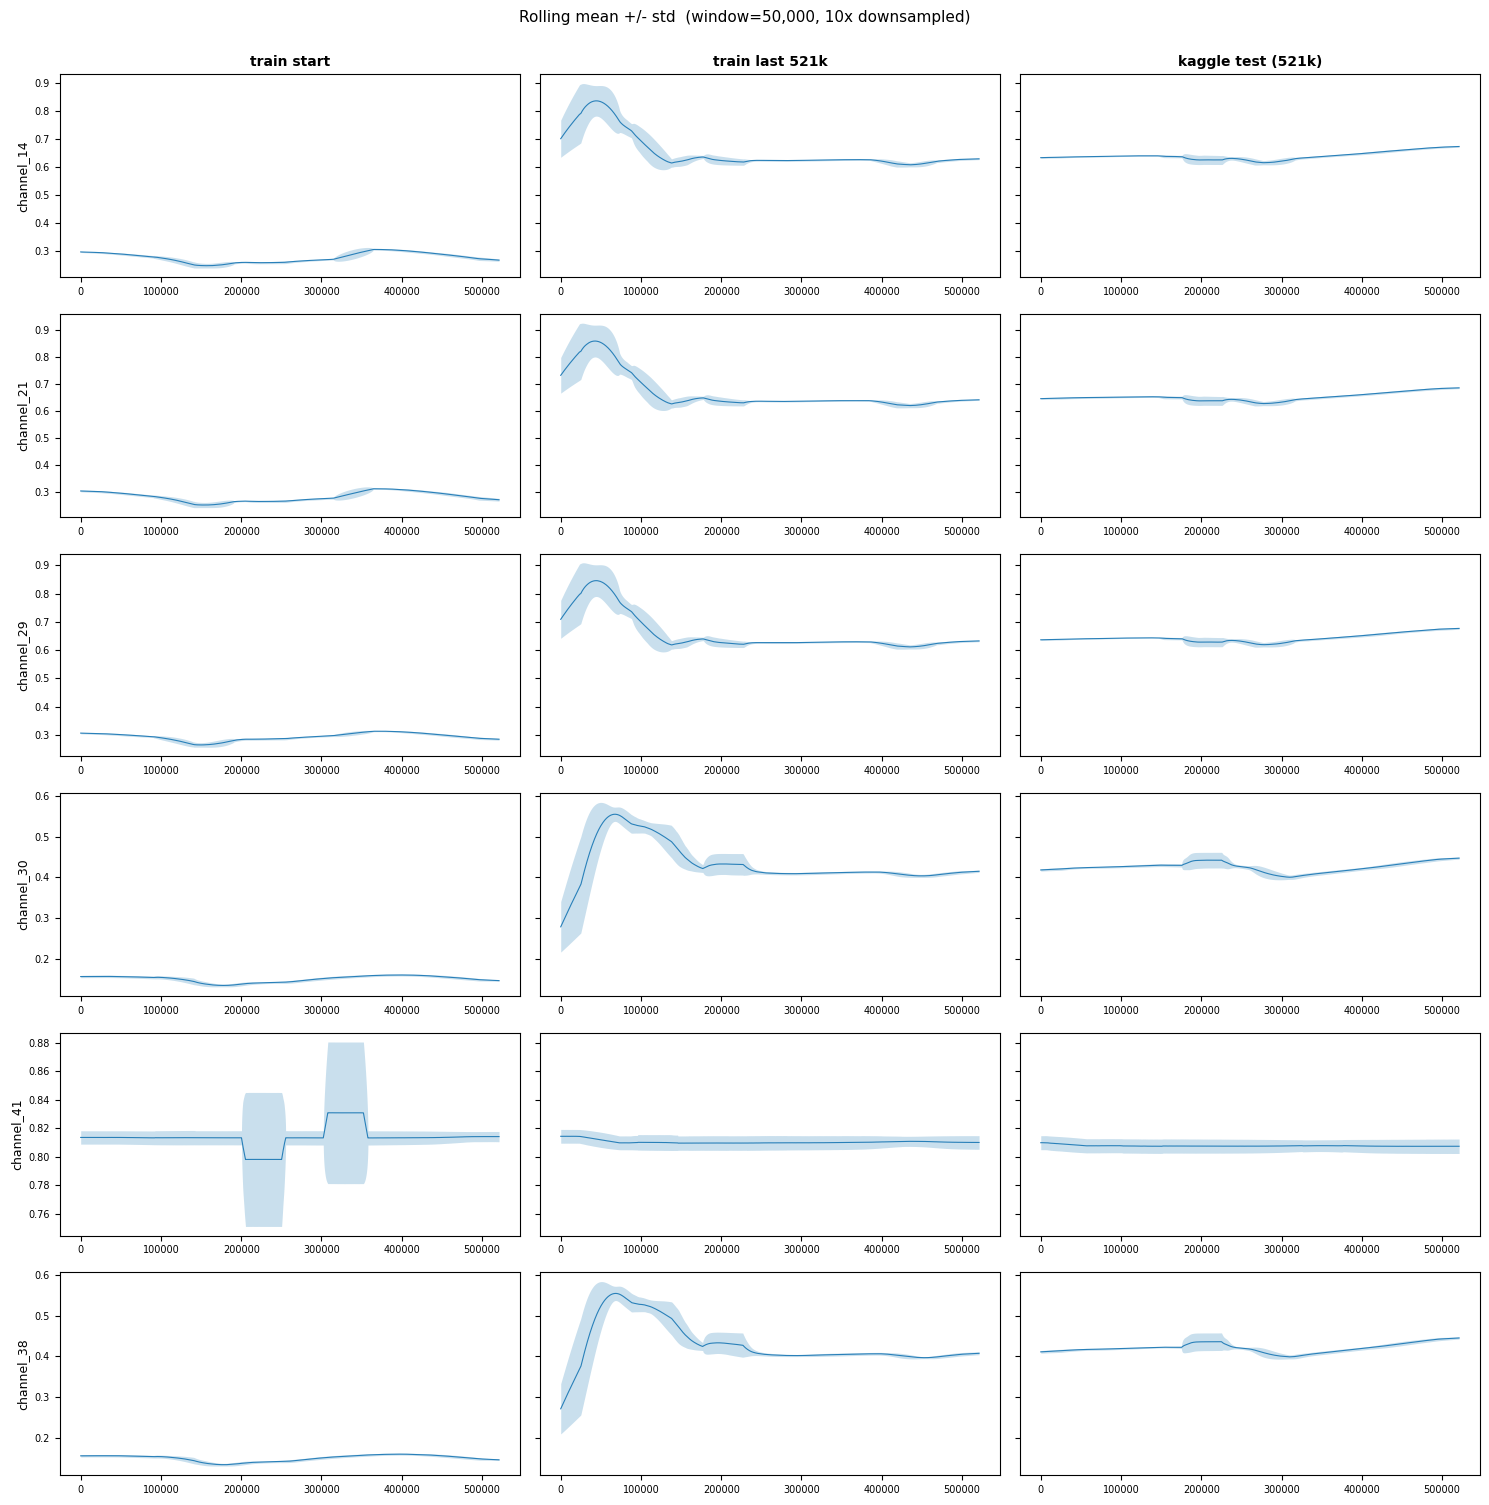

In [3]:
def rolling_stats(s: pd.Series, window: int, stride: int):
    """Centered rolling mean +/- std, downsampled to `stride` for plotting."""
    m = s.rolling(window, min_periods=1, center=True).mean().to_numpy()
    d = s.rolling(window, min_periods=1, center=True).std().to_numpy()
    idx = np.arange(len(s))
    return idx[::stride], m[::stride], d[::stride]


regions = [
    ('train start',        train_cols.iloc[:KAGGLE_TEST_LEN].reset_index(drop=True)),
    ('train last 521k',    train_cols.iloc[proxy_start:].reset_index(drop=True)),
    ('kaggle test (521k)', test_cols.reset_index(drop=True)),
]

fig, axes = plt.subplots(
    len(CHANNELS), len(regions),
    figsize=(15, 2.5 * len(CHANNELS)),
    sharey='row',
)

for i, ch in enumerate(CHANNELS):
    for j, (name, df) in enumerate(regions):
        ax = axes[i, j]
        idx, m, d = rolling_stats(df[ch], WINDOW, STRIDE)
        ax.plot(idx, m, lw=0.8, color=NOMINAL_COLOR)
        ax.fill_between(idx, m - d, m + d, color=NOMINAL_COLOR, alpha=0.25, lw=0)
        if i == 0:
            ax.set_title(name, fontsize=10, fontweight='bold')
        if j == 0:
            ax.set_ylabel(ch, fontsize=9)
        ax.tick_params(labelsize=7)

fig.suptitle(
    f'Rolling mean +/- std  (window={WINDOW:,}, {STRIDE}x downsampled)',
    fontsize=11, y=1.00,
)
fig.tight_layout()
plt.show()

# Free the 4-column dataframes — we won't need them in later sections.
del train_cols, test_cols

## Channel-Mask-Ablation for top-k scoring

NB 18 Section 6 identified a **lock-step Group A** of 10 drifters (`channel_14, 15, 21, 22, 23, 29, 30, 31, 38, 39`) with `|test_intern_z| >= 1.6`. These are the channels that push top-k reconstruction MSE above the val-tuned threshold in test_intern — not because they contain anomalies, but because their baseline has shifted.

**Ablation question.** If we exclude Group A from the per-window top-k computation — set their MSE to `-inf` before `argpartition` — how much of the NB 14 pathology disappears? Concretely, compare Event F0.5 and ESA F0.5 on **test_intern** (with a val-tuned threshold) for:

| rule          | PCA                              | LSTM-AE                        |
|---            |---                               |---                             |
| baseline      | mean over all 58 channels        | top-5 over all 58 channels     |
| masked        | mean over 48 non-Group-A channels| top-5 over 48 non-Group-A      |

Same reconstruction, same per-channel MSE tensor — only the aggregation over channels changes. A large F0.5 drop from baseline to masked means the baseline score was riding on drift; a small drop means the top-k was actually catching anomalies on other channels.

In [4]:
import json
import joblib
import tensorflow as tf

from sentinel.ml_logic.scorer import score_report, broadcast_window_scores_to_rows
from sentinel.ml_logic.thresholds import tune_threshold

# --- Load processed val + test_intern (scaled, 58 target channels) ---
PROC = PROCESSED_DIR
cfg  = json.loads((PROC / 'preprocessing_config.json').read_text())
TARGET_CHANNELS = cfg['target_channels']

X_val  = np.load(PROC / 'val_scaled.npy').astype(np.float32)
y_val  = np.load(PROC / 'y_val.npy').astype(np.int8)
X_ti   = np.load(PROC / 'test_intern_scaled.npy').astype(np.float32)
y_ti   = np.load(PROC / 'y_test_intern.npy').astype(np.int8)
print(f'val         : X={X_val.shape}  y_anom={int(y_val.sum()):,}')
print(f'test_intern : X={X_ti.shape}   y_anom={int(y_ti.sum()):,}')

# --- Group A: 10 lock-step drifters (|test_intern_z| >= 1.6, NB 18 Section 6) ---
GROUP_A_NAMES = ['channel_14', 'channel_15', 'channel_21', 'channel_22', 'channel_23',
                 'channel_29', 'channel_30', 'channel_31', 'channel_38', 'channel_39']
name_to_idx = {c: i for i, c in enumerate(TARGET_CHANNELS)}
mask_idx = np.array([name_to_idx[c] for c in GROUP_A_NAMES], dtype=np.int64)
keep_idx = np.setdiff1d(np.arange(len(TARGET_CHANNELS)), mask_idx)
print(f'\nGroup A indices (mask) : {mask_idx.tolist()}')
print(f'kept channels          : {len(keep_idx)} / {len(TARGET_CHANNELS)}')

# --- Load models ---
pca  = joblib.load(MODELS_DIR / 'pca.pkl')
lstm = tf.keras.models.load_model(MODELS_DIR / 'lstm_ae.keras', compile=False)

# --- Per-window per-channel MSE for both splits on both models (one pass each) ---
# window_channel_mse shape: (n_win, n_feat). Aggregation over channels = the score.
print('\nScoring PCA + LSTM on val and test_intern (one forward pass per combo)...')
rep_pca_val  = score_report(pca,  X_val, topk=None)
rep_pca_ti   = score_report(pca,  X_ti,  topk=None)
rep_lstm_val = score_report(lstm, X_val, topk=5)    # topk=5 as requested
rep_lstm_ti  = score_report(lstm, X_ti,  topk=5)
print('  done.')

def aggregate(win_ch_mse: np.ndarray, rule: str, mask: np.ndarray | None, topk: int):
    '''Aggregate (n_win, n_feat) per-channel MSE into (n_win,) window scores.
    rule="mean": mean over unmasked channels (PCA). rule="topk": mean of top-k
    per window after setting masked channels to -inf (LSTM).'''
    x = win_ch_mse.copy()
    if mask is not None and len(mask):
        if rule == 'mean':
            x[:, mask] = np.nan
            return np.nanmean(x, axis=1).astype(np.float32)
        else:
            x[:, mask] = -np.inf
    if rule == 'mean':
        return x.mean(axis=1).astype(np.float32)
    vals = np.partition(x, -topk, axis=1)[:, -topk:]
    return vals.mean(axis=1).astype(np.float32)

def evaluate(model_name: str, rule: str, topk: int,
             rep_val: dict, rep_ti: dict,
             mask: np.ndarray | None, tag: str) -> dict:
    win_val = aggregate(rep_val['window_channel_mse'], rule, mask, topk)
    win_ti  = aggregate(rep_ti['window_channel_mse'],  rule, mask, topk)
    row_val = broadcast_window_scores_to_rows(win_val, len(y_val))
    row_ti  = broadcast_window_scores_to_rows(win_ti,  len(y_ti))

    tune = tune_threshold(row_val, y_val, metric_fn=event_f05)
    thr  = tune['threshold']
    y_hat_ti = (row_ti > thr).astype(np.int8)

    ef  = event_f05(y_ti, y_hat_ti)
    esa = corrected_event_f05(y_ti, y_hat_ti)
    return {
        'model' : model_name, 'rule': tag, 'thr_val': round(thr, 6),
        'event_f05' : round(ef['f_score'],  4),
        'event_prec': round(ef['precision'], 4),
        'event_rec' : round(ef['recall'],    4),
        'esa_f05'   : round(esa['f_score'], 4),
        'esa_prec'  : round(esa['precision'], 4),
        'esa_tnr'   : round(esa['tnr'], 4),
    }

rows = [
    evaluate('PCA',     'mean', 0, rep_pca_val,  rep_pca_ti,  None,     'baseline (all 58)'),
    evaluate('PCA',     'mean', 0, rep_pca_val,  rep_pca_ti,  mask_idx, 'masked (48, no Group A)'),
    evaluate('LSTM-AE', 'topk', 5, rep_lstm_val, rep_lstm_ti, None,     'baseline top-5 of 58'),
    evaluate('LSTM-AE', 'topk', 5, rep_lstm_val, rep_lstm_ti, mask_idx, 'masked top-5 of 48'),
]
ablation = pd.DataFrame(rows)
print('\n--- Channel-Mask Ablation on test_intern (val-tuned threshold, metric=event_f05) ---')
print(ablation.to_string(index=False))

val         : X=(2232277, 58)  y_anom=246,463
test_intern : X=(2186220, 58)   y_anom=214,961

Group A indices (mask) : [2, 3, 9, 10, 11, 17, 18, 19, 26, 27]
kept channels          : 48 / 58

Scoring PCA + LSTM on val and test_intern (one forward pass per combo)...
  done.

--- Channel-Mask Ablation on test_intern (val-tuned threshold, metric=event_f05) ---
  model                    rule  thr_val  event_f05  event_prec  event_rec  esa_f05  esa_prec  esa_tnr
    PCA       baseline (all 58) 0.060404     0.9843         1.0     0.9259   0.4736     0.422    0.422
    PCA masked (48, no Group A) 0.070715     0.9756         1.0     0.8889   0.4715     0.422    0.422
LSTM-AE    baseline top-5 of 58 1.323612     0.9756         1.0     0.8889   0.4715     0.422    0.422
LSTM-AE      masked top-5 of 48 1.413446     0.9756         1.0     0.8889   0.4715     0.422    0.422


## Shared Group A detrend factor

If Group A channels really move in lock-step — the same physical subsystem slewing — then their per-row mean is a one-number **drift index** for that subsystem. Subtracting it from each Group A channel removes the shared slow component and leaves only channel-specific deviation.

**Recipe.** For every row in `X_val` / `X_test_intern` (scaled, 58 channels):
1. Compute `d[t] = mean(X[t, Group A])` — the drift index.
2. Build a detrended copy `X'` identical to `X` except `X'[t, i] = X[t, i] - d[t]` for each `i` in Group A.
3. Re-score PCA and LSTM on `X'` and plot the score timeline against the original.

This is cheaper than rolling per-channel baselines (one mean per row vs a rolling median per channel) and diagnostic: if the shared-factor subtraction already flattens the val|test_intern step in the MSE timeline, the drift was indeed a single shared mode, not 10 independent drifts.

--- Shared Group A detrend on test_intern (val-tuned threshold) ---
  model   variant  thr_val  event_f05  event_prec  event_rec  esa_f05  esa_tnr
    PCA  original 0.060404     0.9843      1.0000     0.9259   0.4736   0.4220
    PCA detrended 0.064170     0.9843      1.0000     0.9259   0.4736   0.4220
LSTM-AE  original 1.323612     0.9756      1.0000     0.8889   0.4715   0.4220
LSTM-AE detrended 1.272210     0.3165      0.2717     0.9259   0.1108   0.3343


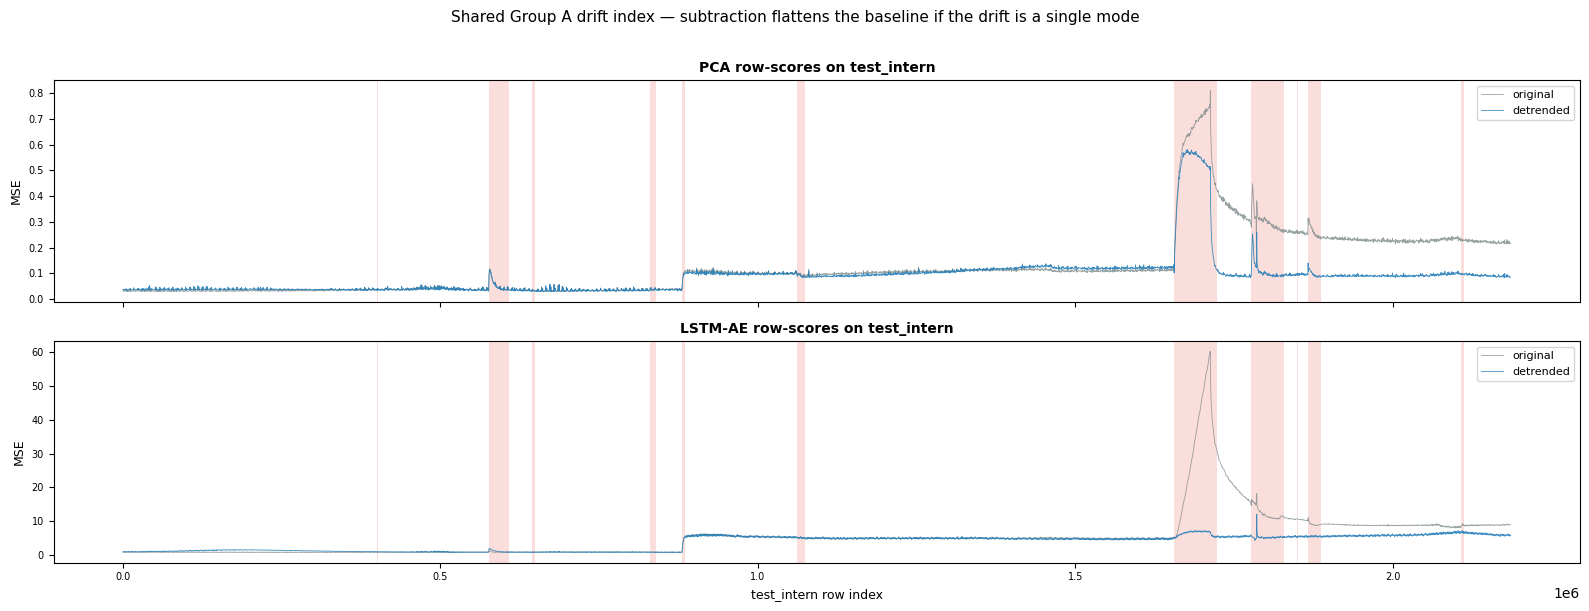

In [5]:
from sentinel.ml_logic.scorer import score_windows

def detrend_group_a(X: np.ndarray, group_idx: np.ndarray) -> np.ndarray:
    '''Subtract the per-row mean of `group_idx` channels from those channels only.'''
    X_out = X.copy()
    drift_index = X[:, group_idx].mean(axis=1, keepdims=True)   # (n_rows, 1)
    X_out[:, group_idx] = X_out[:, group_idx] - drift_index
    return X_out

X_val_dt = detrend_group_a(X_val, mask_idx)
X_ti_dt  = detrend_group_a(X_ti,  mask_idx)

# Re-score original vs detrended with the production settings
# (PCA: topk=None, LSTM: topk=5 for comparability with the ablation above).
scores = {
    ('PCA',     'original')  : (score_windows(pca,  X_val,    topk=None),
                                 score_windows(pca,  X_ti,     topk=None)),
    ('PCA',     'detrended') : (score_windows(pca,  X_val_dt, topk=None),
                                 score_windows(pca,  X_ti_dt,  topk=None)),
    ('LSTM-AE', 'original')  : (score_windows(lstm, X_val,    topk=5),
                                 score_windows(lstm, X_ti,     topk=5)),
    ('LSTM-AE', 'detrended') : (score_windows(lstm, X_val_dt, topk=5),
                                 score_windows(lstm, X_ti_dt,  topk=5)),
}

# Tune on val for each variant, evaluate on test_intern.
rows = []
for (model, variant), (sv, st) in scores.items():
    thr = tune_threshold(sv, y_val, metric_fn=event_f05)['threshold']
    y_hat = (st > thr).astype(np.int8)
    ef  = event_f05(y_ti, y_hat)
    esa = corrected_event_f05(y_ti, y_hat)
    rows.append({
        'model': model, 'variant': variant, 'thr_val': round(thr, 6),
        'event_f05' : round(ef['f_score'],  4),
        'event_prec': round(ef['precision'],4),
        'event_rec' : round(ef['recall'],   4),
        'esa_f05'   : round(esa['f_score'], 4),
        'esa_tnr'   : round(esa['tnr'],     4),
    })
detrend_table = pd.DataFrame(rows)
print('--- Shared Group A detrend on test_intern (val-tuned threshold) ---')
print(detrend_table.to_string(index=False))

# --- Timeline plot: original vs detrended row-scores on test_intern ---
from sentinel.ml_logic.data import find_anomaly_segments

DS = 500
idx = np.arange(0, len(y_ti), DS)
segs = find_anomaly_segments(y_ti)

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
for ax, model in zip(axes, ['PCA', 'LSTM-AE']):
    s_orig = scores[(model, 'original')][1]
    s_det  = scores[(model, 'detrended')][1]
    ax.plot(idx, s_orig[idx], lw=0.6, color='#7f8c8d', label='original', alpha=0.8)
    ax.plot(idx, s_det[idx],  lw=0.6, color=NOMINAL_COLOR, label='detrended', alpha=0.9)
    for s in segs:
        ax.axvspan(s['start'], s['end'], color=ANOMALY_COLOR, alpha=0.18, linewidth=0)
    ax.set_title(f'{model} row-scores on test_intern', fontsize=10, fontweight='bold')
    ax.set_ylabel('MSE', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel('test_intern row index', fontsize=9)
fig.suptitle('Shared Group A drift index — subtraction flattens the baseline if the drift is a single mode',
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

## Quiet channels — drift is subsystem-specific, not time-of-mission

NB 18 Section 6 flagged **9 quiet channels** — `channel_42`, `channel_64`, `channel_65`, `channel_70`–`channel_75` — with `|z| < 0.5` and `|std_ratio - 1| < 0.3` on every split (train / val / test_intern / kaggle_test). They do **not** drift between regimes.

**Why this matters.** If the drift were a global "time-of-mission" effect — sensors ageing, calibration walking over the satellite's lifetime — *every* channel should show some shift between train and the later splits. The fact that 9 of 58 channels are perfectly stationary while Group A slams by several σ rules out "everything drifts a little" as the explanation.

So the drift is **subsystem-specific**:
- Group A (10 channels) is one physical subsystem shifting regime. The shared-factor detrend above is aimed at exactly this mode.
- Group B (`channel_57–60`, low-variance) is a separate, smaller sub-cluster with its own behaviour.
- The quiet channels (`42`, `64–75`) are a natural drift-free reference set — useful as a sanity check if we ever want to normalise against a "healthy subsystem" signal.

Practical consequence: we do not need a "mission-age" feature or a global detrender. Targeted corrections on Group A (and possibly Group B) are enough to close the NB 14 gap.